<a href="https://colab.research.google.com/github/phylist404/credit_scoring_project/blob/main/credit_scoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [79]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import xgboost
import catboost

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV


In [6]:
from google.colab import files
uploaded = files.upload()

Saving bank.csv to bank.csv


In [63]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


In [14]:
data_bank = pd.read_csv('bank.csv', sep=';') # made pandas DataFrame

In [15]:
data_bank.head(20)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
5,35,management,single,tertiary,no,747,no,no,cellular,23,feb,141,2,176,3,failure,no
6,36,self-employed,married,tertiary,no,307,yes,no,cellular,14,may,341,1,330,2,other,no
7,39,technician,married,secondary,no,147,yes,no,cellular,6,may,151,2,-1,0,unknown,no
8,41,entrepreneur,married,tertiary,no,221,yes,no,unknown,14,may,57,2,-1,0,unknown,no
9,43,services,married,primary,no,-88,yes,yes,cellular,17,apr,313,1,147,2,failure,no


In [16]:
data_bank.shape

(4521, 17)

In [17]:
data_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


Our dataframe contains 17 columns and 4521 rows. It contains 10 categorical features and the remaining 6 are numerical. But perhaps there are also categorical ones hidden among them; we just don’t know yet.

In [18]:
data_bank.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


Numerical features have different scales.

In [19]:
data_isna = data_bank.isna().sum()

<BarContainer object of 17 artists>

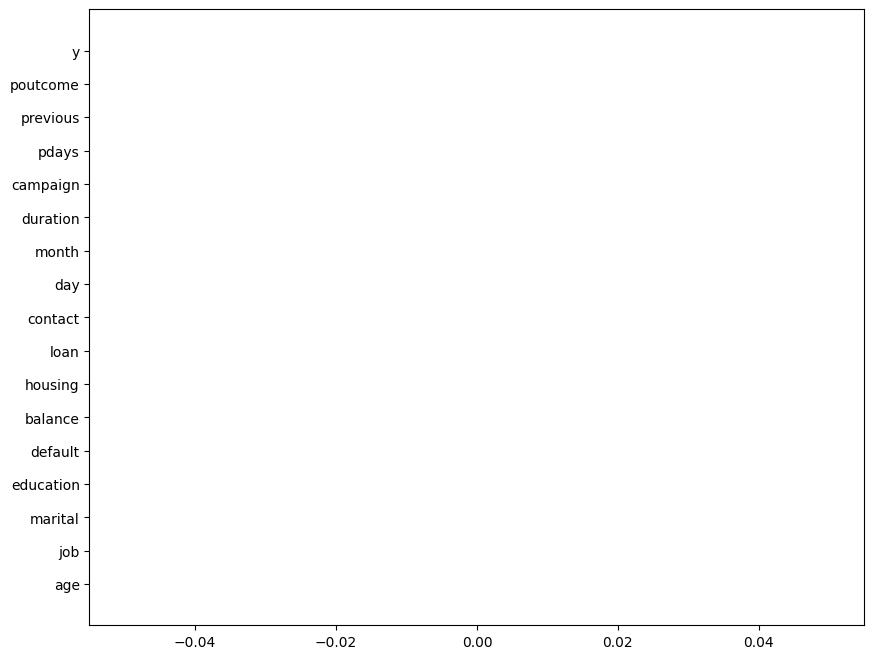

In [20]:
plt.figure(figsize=(10,8))

plt.barh(y=data_isna.index, width=data_isna.values)

The data frame does not contain any missing values. This greatly simplifies the task.

In [21]:
def sns_plot(df: pd.DataFrame, feature: str, bins=2, color="#3498db", is_bool=False):

    plt.figure(figsize=(6,4)) # set the graph dimensions

    # Descriptive statistics of numerical features
    display(df[feature].describe())

    #Histogram
    sns.histplot(
        data=df,
        x=feature, # the very sign
        bins=bins, # the number of bars in the histogram
        color=color,
        edgecolor='black'
    )

    #Axis labels
    plt.title(f"Распределение признака '{feature}'", fontsize=16)
    plt.xlabel(feature, fontsize=12)
    plt.ylabel("Количество", fontsize=12)
    if is_bool: # in the function arguments
        plt.xticks([0,1], ["False", "True"])  # we assign Boolean values

    plt.show()

Start with the numerical features. More precisely, with 'int'.

In [22]:
num_col = data_bank.select_dtypes(exclude='O').columns.tolist()
num_col # list numerical columns

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

,age
count,4521.000000
mean,41.170095
std,10.576211
min,19.000000
25%,33.000000
50%,39.000000
75%,49.000000
max,87.000000


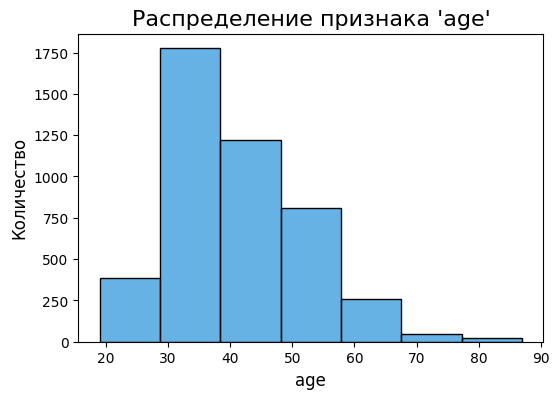

In [23]:
sns_plot(data_bank, 'age', bins=7)

The graph shows that there are no significant outliers. However, the values are not distributed evenly. Pensioners are given significantly fewer loans than others.

,balance
count,4521.000000
mean,1422.657819
std,3009.638142
min,-3313.000000
25%,69.000000
50%,444.000000
75%,1480.000000
max,71188.000000


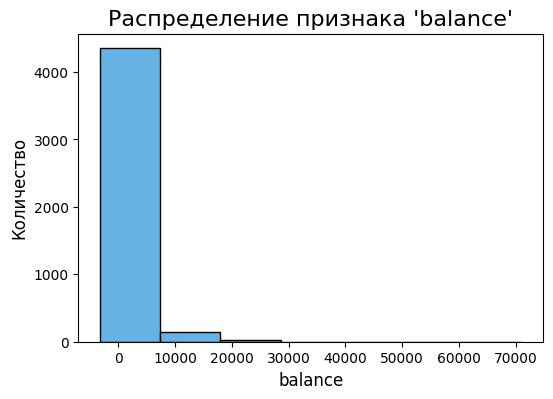

In [24]:
sns_plot(data_bank, 'balance', bins=7)

A significant difference in values. A large leftward skew.

In [25]:
# We’ll create new features based on the past, but we’ll normalize them.
data_bank['has_balance'] = (data_bank['balance'] > 0).astype(int)
data_bank['balance_amount_log'] = np.log1p(data_bank['balance'].clip(lower=0))
data_bank = data_bank.drop(columns=['balance'])

,balance_amount_log
count,4521.000000
mean,5.335294
std,2.799276
min,0.000000
25%,4.248495
50%,6.098074
75%,7.300473
max,11.173094


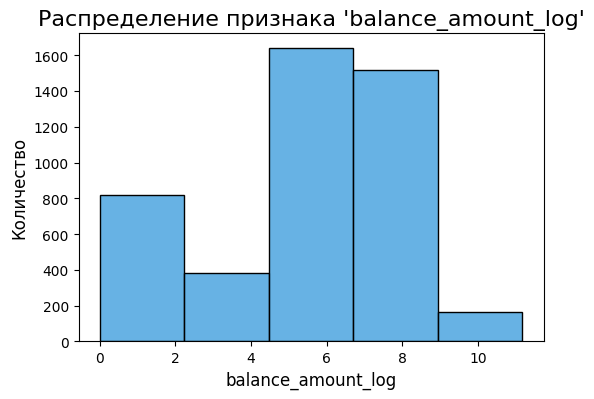

In [26]:
sns_plot(data_bank, 'balance_amount_log', bins=5)

There is no obvious imbalance at present

,day
count,4521.000000
mean,15.915284
std,8.247667
min,1.000000
25%,9.000000
50%,16.000000
75%,21.000000
max,31.000000


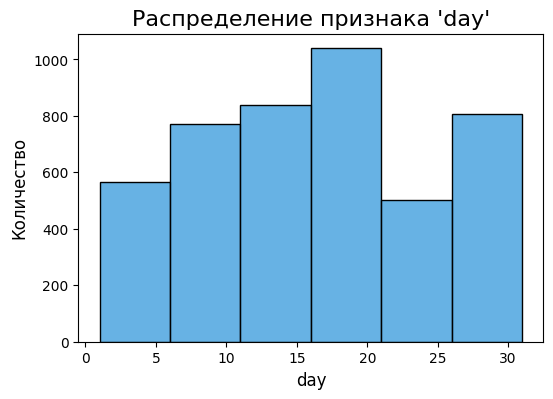

In [27]:
sns_plot(data_bank, 'day', bins=6)

In my opinion, I don’t consider this feature to be significant in our model. Let’s remove it.

In [28]:
data_bank = data_bank.drop('day', axis=1)

,duration
count,4521.000000
mean,263.961292
std,259.856633
min,4.000000
25%,104.000000
50%,185.000000
75%,329.000000
max,3025.000000


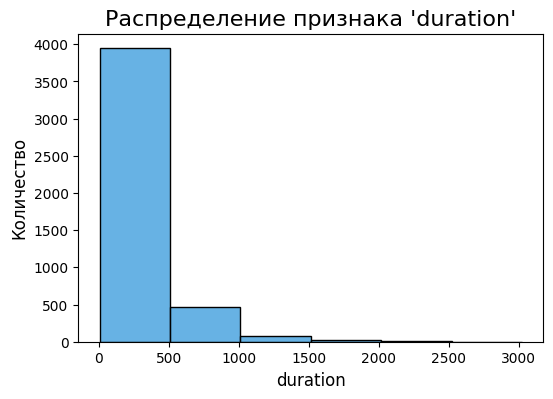

In [29]:
sns_plot(data_bank, 'duration', bins=6)

The situation is similar to a balance.

In [30]:
data_bank['duration_amount_log'] = np.log1p(data_bank['duration'].clip(lower=0))
data_bank = data_bank.drop(columns=['duration'])

,duration_amount_log
count,4521.000000
mean,5.185131
std,0.938617
min,1.609438
25%,4.653960
50%,5.225747
75%,5.799093
max,8.014997


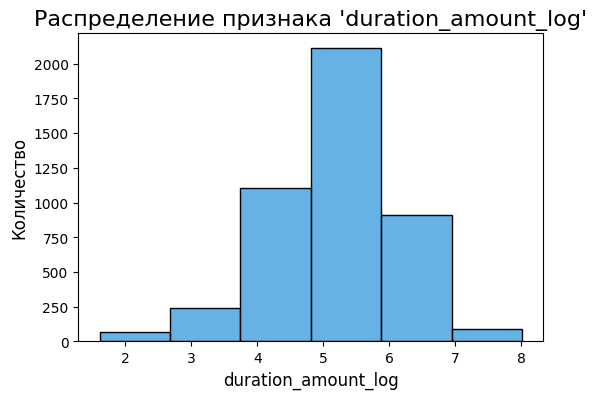

In [31]:
sns_plot(data_bank, 'duration_amount_log', bins=6)

It's better.

,campaign
count,4521.000000
mean,2.793630
std,3.109807
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,50.000000


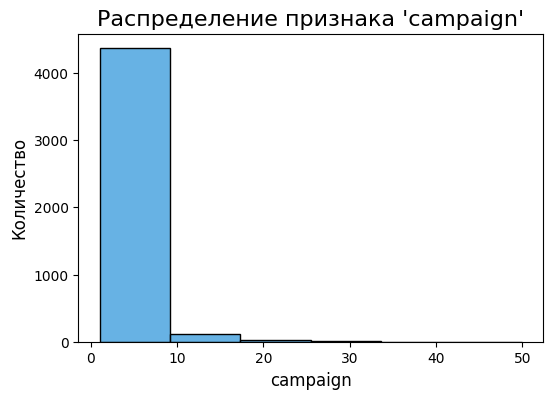

In [32]:
sns_plot(data_bank, 'campaign', bins=6)

Similarly.

In [33]:
data_bank['campaignamount_log'] = np.log1p(data_bank['campaign'].clip(lower=0))
data_bank = data_bank.drop(columns=['campaign'])

,campaignamount_log
count,4521.000000
mean,1.164463
std,0.516092
min,0.693147
25%,0.693147
50%,1.098612
75%,1.386294
max,3.931826


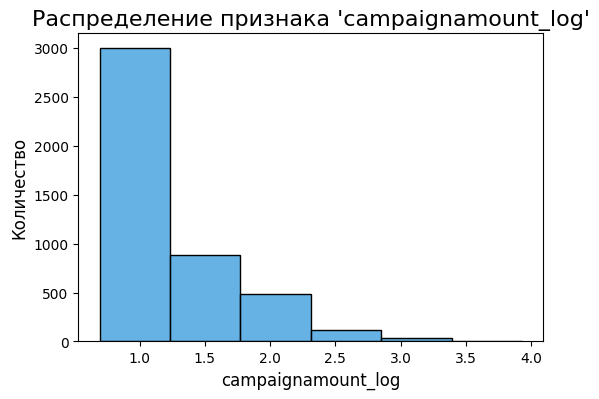

In [34]:
sns_plot(data_bank, 'campaignamount_log', bins=6)

Better.

,pdays
count,4521.000000
mean,39.766645
std,100.121124
min,-1.000000
25%,-1.000000
50%,-1.000000
75%,-1.000000
max,871.000000


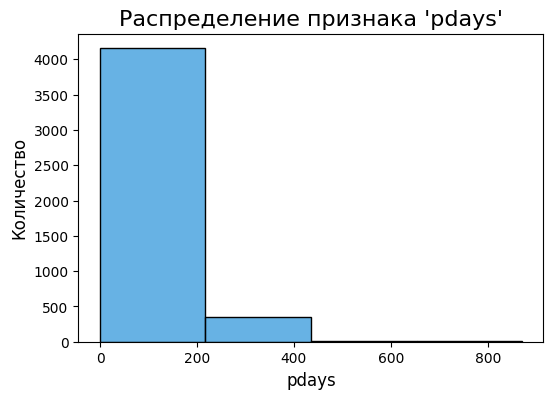

In [35]:
sns_plot(data_bank, 'pdays', bins=4)

In [36]:
data_bank['was_contacted'] = (data_bank['pdays'] != -1).astype(int)
data_bank['pdays_recency'] = pd.cut(data_bank['pdays'],
                             bins=[-2, -1, 0, 7, 30, 90, 365, float('inf')],
                             labels=['No Contact', 'Today', 'Week',
                                    'Month', '3 Months', 'Year', '> Year'])
data_bank = pd.get_dummies(data_bank, columns=['pdays_recency'], prefix='pdays')
data_bank = data_bank.drop(columns=['pdays'])

,previous
count,4521.000000
mean,0.542579
std,1.693562
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,25.000000


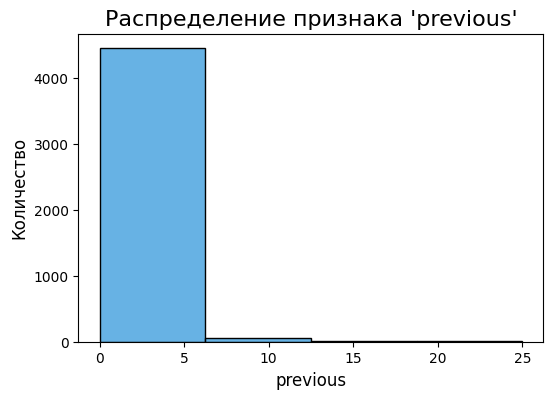

In [37]:
sns_plot(data_bank, 'previous', bins=4)

In [38]:
data_bank['had_previous_contact'] = (data_bank['previous'] > 0).astype(int)
data_bank['previous_category'] = pd.cut(data_bank['previous'],
                                 bins=[-1, 0, 1, 3, 5, 10, float('inf')],
                                 labels=['0', '1', '2-3', '4-5', '6-10', '10+'])
data_bank = pd.get_dummies(data_bank, columns=['previous_category'], prefix='prev')
data_bank = data_bank.drop(columns=['previous'])

In [39]:
data_bank

,age,job,marital,education,default,housing,loan,contact,month,poutcome,...,pdays_3 Months,pdays_Year,pdays_> Year,had_previous_contact,prev_0,prev_1,prev_2-3,prev_4-5,prev_6-10,prev_10+
0,30,unemployed,married,primary,no,no,no,cellular,oct,unknown,...,False,False,False,0,True,False,False,False,False,False
1,33,services,married,secondary,no,yes,yes,cellular,may,failure,...,False,True,False,1,False,False,False,True,False,False
2,35,management,single,tertiary,no,yes,no,cellular,apr,failure,...,False,True,False,1,False,True,False,False,False,False
3,30,management,married,tertiary,no,yes,yes,unknown,jun,unknown,...,False,False,False,0,True,False,False,False,False,False
4,59,blue-collar,married,secondary,no,yes,no,unknown,may,unknown,...,False,False,False,0,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,married,secondary,no,yes,no,cellular,jul,unknown,...,False,False,False,0,True,False,False,False,False,False
4517,57,self-employed,married,tertiary,yes,yes,yes,unknown,may,unknown,...,False,False,False,0,True,False,False,False,False,False
4518,57,technician,married,secondary,no,no,no,cellular,aug,unknown,...,False,False,False,0,True,False,False,False,False,False
4519,28,blue-collar,married,secondary,no,no,no,cellular,feb,other,...,False,True,False,1,False,False,True,False,False,False


In [40]:
cat_col = data_bank.select_dtypes(include='O').columns.tolist()
cat_col

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome',
 'y']

In [41]:
for col in cat_col:
    print(f'{col}: {data_bank[col].nunique()}')

job: 12
marital: 3
education: 4
default: 2
housing: 2
loan: 2
contact: 3
month: 12
poutcome: 4
y: 2


You can see the number of unique values ​​in each categorical feature. Let's start converting these features into numerical ones.

In [44]:
# 1. job - One-Hot Encoding
data_bank = pd.get_dummies(data_bank, columns=['job'], prefix='job', drop_first=True)

# 2. marital - One-Hot Encoding
data_bank = pd.get_dummies(data_bank, columns=['marital'], prefix='marital', drop_first=True)

# 3. education - Ordinal Encoding
education_order = {
    'primary': 1,
    'secondary': 2,
    'tertiary': 3,
    'unknown': 0
}
data_bank['education_encoded'] = data_bank['education'].map(education_order)
data_bank = data_bank.drop(columns=['education'])

# 4. default - Binary Encoding
data_bank['has_default'] = (data_bank['default'] == 'yes').astype(int)
data_bank = data_bank.drop(columns=['default'])

# 5. housing - Binary Encoding
data_bank['has_housing'] = (data_bank['housing'] == 'yes').astype(int)
data_bank = data_bank.drop(columns=['housing'])

# 6. loan - Binary Encoding
data_bank['has_loan'] = (data_bank['loan'] == 'yes').astype(int)
data_bank = data_bank.drop(columns=['loan'])

# 7. contact - One-Hot Encoding
data_bank = pd.get_dummies(data_bank, columns=['contact'], prefix='contact', drop_first=True)

# 8. month - Cyclic Encoding
month_mapping = {
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4,
    'may': 5, 'jun': 6, 'jul': 7, 'aug': 8,
    'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
}
data_bank['month_num'] = data_bank['month'].map(month_mapping)
data_bank['month_sin'] = np.sin(2 * np.pi * data_bank['month_num'] / 12)
data_bank['month_cos'] = np.cos(2 * np.pi * data_bank['month_num'] / 12)
data_bank = data_bank.drop(columns=['month', 'month_num'])

# 9. poutcome - One-Hot Encoding
data_bank = pd.get_dummies(data_bank, columns=['poutcome'], prefix='poutcome', drop_first=True)

# 10. y - Target Variable
if data_bank['y'].dtype == 'object':
    data_bank['y'] = (data_bank['y'] == 'yes').astype(int)

At this stage, all features—whether ordinal, binary, or standard categorical—have been encoded. Everything can be seen above.

In [45]:
data_bank

,age,y,has_balance,balance_amount_log,duration_amount_log,campaignamount_log,was_contacted,pdays_No Contact,pdays_Today,pdays_Week,...,has_default,has_housing,has_loan,contact_telephone,contact_unknown,month_sin,month_cos,poutcome_other,poutcome_success,poutcome_unknown
0,30,0,1,7.488853,4.382027,0.693147,0,True,False,False,...,0,0,0,False,False,-8.660254e-01,0.500000,False,False,True
1,33,0,1,8.474286,5.398163,0.693147,1,False,False,False,...,0,1,1,False,False,5.000000e-01,-0.866025,False,False,False
2,35,0,1,7.208600,5.225747,0.693147,1,False,False,False,...,0,1,0,False,False,8.660254e-01,-0.500000,False,False,False
3,30,0,1,7.297768,5.298317,1.609438,0,True,False,False,...,0,1,1,False,True,1.224647e-16,-1.000000,False,False,True
4,59,0,0,0.000000,5.424950,0.693147,0,True,False,False,...,0,1,0,False,True,5.000000e-01,-0.866025,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,0,0,0.000000,5.799093,1.791759,0,True,False,False,...,0,1,0,False,False,-5.000000e-01,-0.866025,False,False,True
4517,57,0,0,0.000000,5.036953,0.693147,0,True,False,False,...,1,1,1,False,True,5.000000e-01,-0.866025,False,False,True
4518,57,0,1,5.690359,5.023881,2.484907,0,True,False,False,...,0,0,0,False,False,-8.660254e-01,-0.500000,False,False,True
4519,28,0,1,7.037028,4.867534,1.609438,1,False,False,False,...,0,0,0,False,False,8.660254e-01,0.500000,True,False,False


The bulk of the data work is done. Now, let's start selecting the optimal machine learning model.

<Axes: xlabel='y', ylabel='Count'>

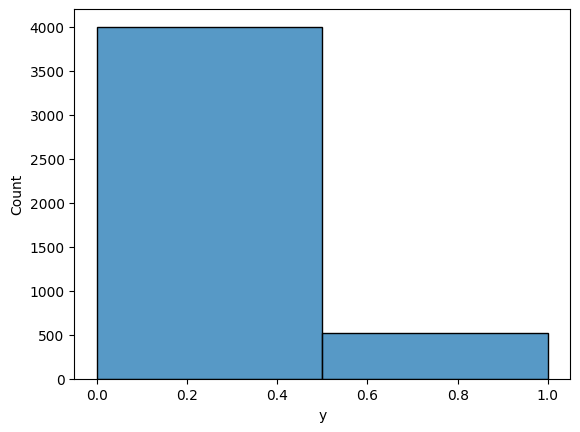

In [53]:
sns.histplot(data=data_bank, x='y', bins=2)

As we can see, we are dealing with binary classification tasks. Let us consider models such as Decision Tree, Random Forest, XGBoost, and CatBoost.

In [57]:
X = data_bank.drop('y', axis=1)
y = data_bank['y']

In [61]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=67, stratify=y   # Split the data into a test set.

    )
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, random_state=67, test_size=0.25, stratify=y_temp # Separate validation set from remaining data
)

In [70]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=67),
    'Random Forest': RandomForestClassifier(random_state=67, n_jobs=-1),
    'XGBoost': XGBClassifier(random_state=67, use_label_encoder=False, eval_metric='logloss'),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0, allow_writing_files=False)
}

# Create models

baseline_results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    y_pred = (y_pred_proba >= 0.5).astype(int)

    baseline_results[name] = {
        'model': name,
        'roc_auc': roc_auc_score(y_val, y_pred_proba),
        'f1': f1_score(y_val, y_pred)
    }


Training Decision Tree...

Training Random Forest...

Training XGBoost...


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [20:48:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Training CatBoost...


In [71]:
baseline_results

{'Decision Tree': {'model': 'Decision Tree',
  'roc_auc': np.float64(0.6732211538461539),
  'f1': 0.41284403669724773},
 'Random Forest': {'model': 'Random Forest',
  'roc_auc': np.float64(0.8836358173076924),
  'f1': 0.2463768115942029},
 'XGBoost': {'model': 'XGBoost',
  'roc_auc': np.float64(0.8871274038461539),
  'f1': 0.37209302325581395},
 'CatBoost': {'model': 'CatBoost',
  'roc_auc': np.float64(0.8928725961538461),
  'f1': 0.4025157232704403}}

We have now trained our models using standard parameters and conducted an initial check on the validation set. The metric results can be seen above.
Now we’ll start tuning the hyperparameters for it as well.

In [72]:
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced']
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_dt.fit(X_train, y_train)

print(f"Best parameters: {grid_dt.best_params_}")
print(f"Best CV ROC-AUC: {grid_dt.best_score_:.4f}")

best_dt = grid_dt.best_estimator_


Fitting 5 folds for each of 320 candidates, totalling 1600 fits
Best parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 8, 'min_samples_split': 20}
Best CV ROC-AUC: 0.8460


We have now selected the best hyperparameters for the decision tree model. You can see them above.

In [73]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

print(f"Best parameters: {grid_rf.best_params_}")
print(f"Best CV ROC-AUC: {grid_rf.best_score_:.4f}")

best_rf = grid_rf.best_estimator_

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best parameters: {'class_weight': 'balanced_subsample', 'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV ROC-AUC: 0.9056


The same applies to each model; we see the result for all of them.

In [74]:
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7, 9],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'scale_pos_weight': [1, 2, 3]
}

grid_xgb = GridSearchCV(
    XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    param_grid_xgb,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)

print(f"Best parameters: {grid_xgb.best_params_}")
print(f"Best CV ROC-AUC: {grid_xgb.best_score_:.4f}")

best_xgb = grid_xgb.best_estimator_

Fitting 5 folds for each of 972 candidates, totalling 4860 fits
Best parameters: {'colsample_bytree': 0.6, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'scale_pos_weight': 1, 'subsample': 0.8}
Best CV ROC-AUC: 0.9066


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [21:18:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


The same applies to each model; we see the result for all of them.

In [77]:
param_grid_cb = {
    'iterations': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [3, 5, 7],
    'l2_leaf_reg': [1, 3, 5, 7],
    'auto_class_weights': [None, 'Balanced']
}

grid_cb = GridSearchCV(
    CatBoostClassifier(random_state=42, verbose=0, allow_writing_files=False),
    param_grid_cb,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_cb.fit(X_train, y_train)

print(f"Best parameters: {grid_cb.best_params_}")
print(f"Best CV ROC-AUC: {grid_cb.best_score_:.4f}")

best_cb = grid_cb.best_estimator_


Fitting 5 folds for each of 216 candidates, totalling 1080 fits


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
540 fits failed out of a total of 1080.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
540 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/catboost/core.py", line 5547, in fit
    self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, baseline, use_best_model,
    ~~~~~~~~~^^^^^^^^^^^^^^^^^

Best parameters: {'auto_class_weights': 'Balanced', 'depth': 5, 'iterations': 200, 'l2_leaf_reg': 7, 'learning_rate': 0.05}
Best CV ROC-AUC: 0.9094


The same applies to each model; we see the result for all of them.

In [80]:
tuned_models = {
    'Decision Tree': best_dt, # Models with best parametrs
    'Random Forest': best_rf,
    'XGBoost': best_xgb,
    'CatBoost': best_cb
}

val_results = {}

for name, model in tuned_models.items():
    print(f"\nEvaluating {name}...")

    y_pred_proba = model.predict_proba(X_val)[:, 1]
    y_pred = (y_pred_proba >= 0.5).astype(int)

    val_results[name] = {
        'roc_auc': roc_auc_score(y_val, y_pred_proba),
        'f1': f1_score(y_val, y_pred),
        'accuracy': accuracy_score(y_val, y_pred),
        'model': model
    }

    print(f"  ROC-AUC: {val_results[name]['roc_auc']:.4f}")
    print(f"  F1: {val_results[name]['f1']:.4f}")
    print(f"  Accuracy: {val_results[name]['accuracy']:.4f}")


best_model_name = max(val_results, key=lambda x: val_results[x]['roc_auc']) # Choose the best model
best_model = val_results[best_model_name]['model']


Evaluating Decision Tree...
  ROC-AUC: 0.8522
  F1: 0.3265
  Accuracy: 0.8905

Evaluating Random Forest...
  ROC-AUC: 0.8875
  F1: 0.3165
  Accuracy: 0.8805

Evaluating XGBoost...
  ROC-AUC: 0.8973
  F1: 0.3846
  Accuracy: 0.8938

Evaluating CatBoost...
  ROC-AUC: 0.9006
  F1: 0.5081
  Accuracy: 0.8330


In [81]:
best_model

CatBoostClassifier(allow_writing_files=False, auto_class_weights='Balanced', depth=5, iterations=200, l2_leaf_reg=7, learning_rate=0.05, random_state=42, verbose=0)

We found that CatBoost handles our task best; let's test it on the test set.

In [88]:

y_pred_proba = best_cb.predict_proba(X_test)[:, 1]

y_pred = (y_pred_proba >= 0.5).astype(int)


roc_auc = roc_auc_score(y_test, y_pred_proba)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'roc_auc: {roc_auc}')
print(f'accuracy: {accuracy}')
print(f'f1: {f1}')

roc_auc: 0.9176870258330933
accuracy: 0.8419889502762431
f1: 0.5431309904153354


We have now tested our model on the test set. The metric results are higher.